In [2]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

In [3]:
import csv

# Load dataset
animes_df = pd.read_csv('animes.csv')
reviews_df = pd.read_csv('reviews.csv', engine='python', on_bad_lines='skip') # Removed quoting=csv.QUOTE_NONE

print(f"Animes dataset shape: {animes_df.shape}")
print(f"Reviews dataset shape: {reviews_df.shape}")

Animes dataset shape: (19311, 12)
Reviews dataset shape: (6483, 7)


**Data Preprocessing**

1.**Menggabungkan reviews dengan anime**

In [4]:
# Rename kolom 'uid' di animes_df agar tidak bingung saat di-merge
animes_df = animes_df.rename(columns={'uid': 'anime_uid'})

# Handle reviews_df column names: assume 'uid' is review ID, 'anime_uid' is anime ID
# If 'uid' column exists and 'anime_uid' also exists, rename 'uid' to 'review_id'
if 'uid' in reviews_df.columns and 'anime_uid' in reviews_df.columns:
    reviews_df = reviews_df.rename(columns={'uid': 'review_id'})
# If only 'uid' exists, assume it is the anime_uid and rename it accordingly
elif 'uid' in reviews_df.columns:
    reviews_df = reviews_df.rename(columns={'uid': 'anime_uid'})
# No action needed if 'anime_uid' is already the sole identifier.

# Ensure there are no lingering duplicate 'anime_uid' column names (safety check)
duplicated_cols_mask = reviews_df.columns.duplicated(keep='first')
reviews_df = reviews_df.loc[:, ~duplicated_cols_mask]

# Now, convert the 'anime_uid' column to numeric, coercing errors, then drop rows with NaNs and convert to int.
reviews_df['anime_uid'] = pd.to_numeric(reviews_df['anime_uid'], errors='coerce')
reviews_df.dropna(subset=['anime_uid'], inplace=True)
reviews_df['anime_uid'] = reviews_df['anime_uid'].astype(int)

# Convert 'score' column in reviews_df to numeric and clean it BEFORE merging
if 'score' in reviews_df.columns:
    # Convert to numeric, coercing errors (non-numeric values become NaN)
    reviews_df['score'] = pd.to_numeric(reviews_df['score'], errors='coerce')
    # Drop rows where 'score' is NaN, as these are the problematic non-numeric entries
    reviews_df.dropna(subset=['score'], inplace=True)
    # Convert to integer type, as scores are typically whole numbers (e.g., 1-10)
    reviews_df['score'] = reviews_df['score'].astype(int)

# Merge dataset berdasarkan anime_uid
# Kita pakai inner join agar hanya mengambil review dari anime yang metadata-nya tersedia
merged_df = pd.merge(reviews_df, animes_df, on='anime_uid', how='inner')

# Drop kolom yang duplikat atau tidak relevan untuk NLP/Recommender kita saat ini
columns_to_drop = ['link_x', 'link_y', 'ranked', 'popularity', 'members']
# Add 'review_id' to drop list if it exists and is not needed later
if 'review_id' in merged_df.columns:
    columns_to_drop.append('review_id')
merged_df = merged_df.drop(columns=[col for col in columns_to_drop if col in merged_df.columns])

print(f"Merged dataset shape: {merged_df.shape}")
display(merged_df.head(3))

Merged dataset shape: (12966, 12)


,profile,anime_uid,text,score_x,scores,title,synopsis,genre,aired,episodes,score_y,img_url
0,DesolatePsyche,34096,\n \n \n \n ...,8,"{'Overall': '8', 'Story': '8', 'Animation': '8...",Gintama.,After joining the resistance against the bakuf...,"['Action', 'Comedy', 'Historical', 'Parody', '...","Jan 9, 2017 to Mar 27, 2017",12.0,8.94,https://cdn.myanimelist.net/images/anime/3/835...
1,DesolatePsyche,34096,\n \n \n \n ...,8,"{'Overall': '8', 'Story': '8', 'Animation': '8...",Gintama.,After joining the resistance against the bakuf...,"['Action', 'Comedy', 'Historical', 'Parody', '...","Jan 9, 2017 to Mar 27, 2017",12.0,8.94,https://cdn.myanimelist.net/images/anime/3/835...
2,baekbeans,34599,\n \n \n \n ...,10,"{'Overall': '10', 'Story': '10', 'Animation': ...",Made in Abyss,The Abyss—a gaping chasm stretching down into ...,"['Sci-Fi', 'Adventure', 'Mystery', 'Drama', 'F...","Jul 7, 2017 to Sep 29, 2017",13.0,8.83,https://cdn.myanimelist.net/images/anime/6/867...


**2. Basic text cleaning**

In [5]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    # Hapus karakter non-alfanumerik (kecuali spasi dan tanda baca dasar)
    text = re.sub(r'[^a-zA-Z0-9\s.,!?]', '', text)
    # Hapus extra whitespace dan newline
    text = re.sub(r'\s+', ' ', text)
    # Ubah ke lowercase
    text = text.lower().strip()
    return text

print("Cleaning review text (this might take a minute depending on dataset size)...")
# Kita buat kolom baru 'clean_text' agar teks aslinya tetap aman
merged_df['clean_text'] = merged_df['text'].apply(clean_text)

# Drop missing values di kolom text yang sudah dibersihkan
merged_df = merged_df[merged_df['clean_text'].str.strip() != '']

print("Text cleaning complete!")
display(merged_df[['text', 'clean_text', 'score_x']].head())

Cleaning review text (this might take a minute depending on dataset size)...
Text cleaning complete!


,text,clean_text,score_x
0,\n \n \n \n ...,more pics overall 8 story 8 animation 8 sound ...,8
1,\n \n \n \n ...,more pics overall 8 story 8 animation 8 sound ...,8
2,\n \n \n \n ...,more pics overall 10 story 10 animation 10 sou...,10
3,\n \n \n \n ...,more pics overall 10 story 10 animation 10 sou...,10
4,\n \n \n \n ...,more pics overall 7 story 7 animation 9 sound ...,7


In [6]:
# Mengecek dimensi/ukuran dari dataframe
print("Dimensi merged_df:", merged_df.shape)

Dimensi merged_df: (12966, 13)


In [7]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12966 entries, 0 to 12965
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   profile     12966 non-null  object 
 1   anime_uid   12966 non-null  int64  
 2   text        12966 non-null  object 
 3   score_x     12966 non-null  int64  
 4   scores      12966 non-null  object 
 5   title       12966 non-null  object 
 6   synopsis    12952 non-null  object 
 7   genre       12966 non-null  object 
 8   aired       12966 non-null  object 
 9   episodes    12966 non-null  float64
 10  score_y     12966 non-null  float64
 11  img_url     12966 non-null  object 
 12  clean_text  12966 non-null  object 
dtypes: float64(2), int64(2), object(9)
memory usage: 1.3+ MB


In [8]:
# check dataset duplikat dan null
print("Jumlah data duplikat:", merged_df.duplicated().sum())
print("Jumlah data null:", merged_df.isnull().sum().sum())

Jumlah data duplikat: 6483
Jumlah data null: 14


In [9]:
# hapus data duplikat dan null
merged_df.drop_duplicates(inplace=True)
merged_df.dropna(inplace=True)

In [10]:
merged_df.head(5)

,profile,anime_uid,text,score_x,scores,title,synopsis,genre,aired,episodes,score_y,img_url,clean_text
0,DesolatePsyche,34096,\n \n \n \n ...,8,"{'Overall': '8', 'Story': '8', 'Animation': '8...",Gintama.,After joining the resistance against the bakuf...,"['Action', 'Comedy', 'Historical', 'Parody', '...","Jan 9, 2017 to Mar 27, 2017",12.0,8.94,https://cdn.myanimelist.net/images/anime/3/835...,more pics overall 8 story 8 animation 8 sound ...
2,baekbeans,34599,\n \n \n \n ...,10,"{'Overall': '10', 'Story': '10', 'Animation': ...",Made in Abyss,The Abyss—a gaping chasm stretching down into ...,"['Sci-Fi', 'Adventure', 'Mystery', 'Drama', 'F...","Jul 7, 2017 to Sep 29, 2017",13.0,8.83,https://cdn.myanimelist.net/images/anime/6/867...,more pics overall 10 story 10 animation 10 sou...
4,skrn,28891,\n \n \n \n ...,7,"{'Overall': '7', 'Story': '7', 'Animation': '9...",Haikyuu!! Second Season,Following their participation at the Inter-Hig...,"['Comedy', 'Sports', 'Drama', 'School', 'Shoun...","Oct 4, 2015 to Mar 27, 2016",25.0,8.82,https://cdn.myanimelist.net/images/anime/9/766...,more pics overall 7 story 7 animation 9 sound ...
6,edgewalker00,2904,\n \n \n \n ...,9,"{'Overall': '9', 'Story': '9', 'Animation': '9...",Code Geass: Hangyaku no Lelouch R2,"One year has passed since the Black Rebellion,...","['Action', 'Military', 'Sci-Fi', 'Super Power'...","Apr 6, 2008 to Sep 28, 2008",25.0,8.93,https://cdn.myanimelist.net/images/anime/4/939...,more pics overall 9 story 9 animation 9 sound ...
8,aManOfCulture99,4181,\n \n \n \n ...,10,"{'Overall': '10', 'Story': '10', 'Animation': ...",Clannad: After Story,"Clannad: After Story , the sequel to the criti...","['Slice of Life', 'Comedy', 'Supernatural', 'D...","Oct 3, 2008 to Mar 27, 2009",24.0,8.97,https://cdn.myanimelist.net/images/anime/13/24...,more pics overall 10 story 10 animation 8 soun...


In [11]:
!pip install wordcloud matplotlib seaborn

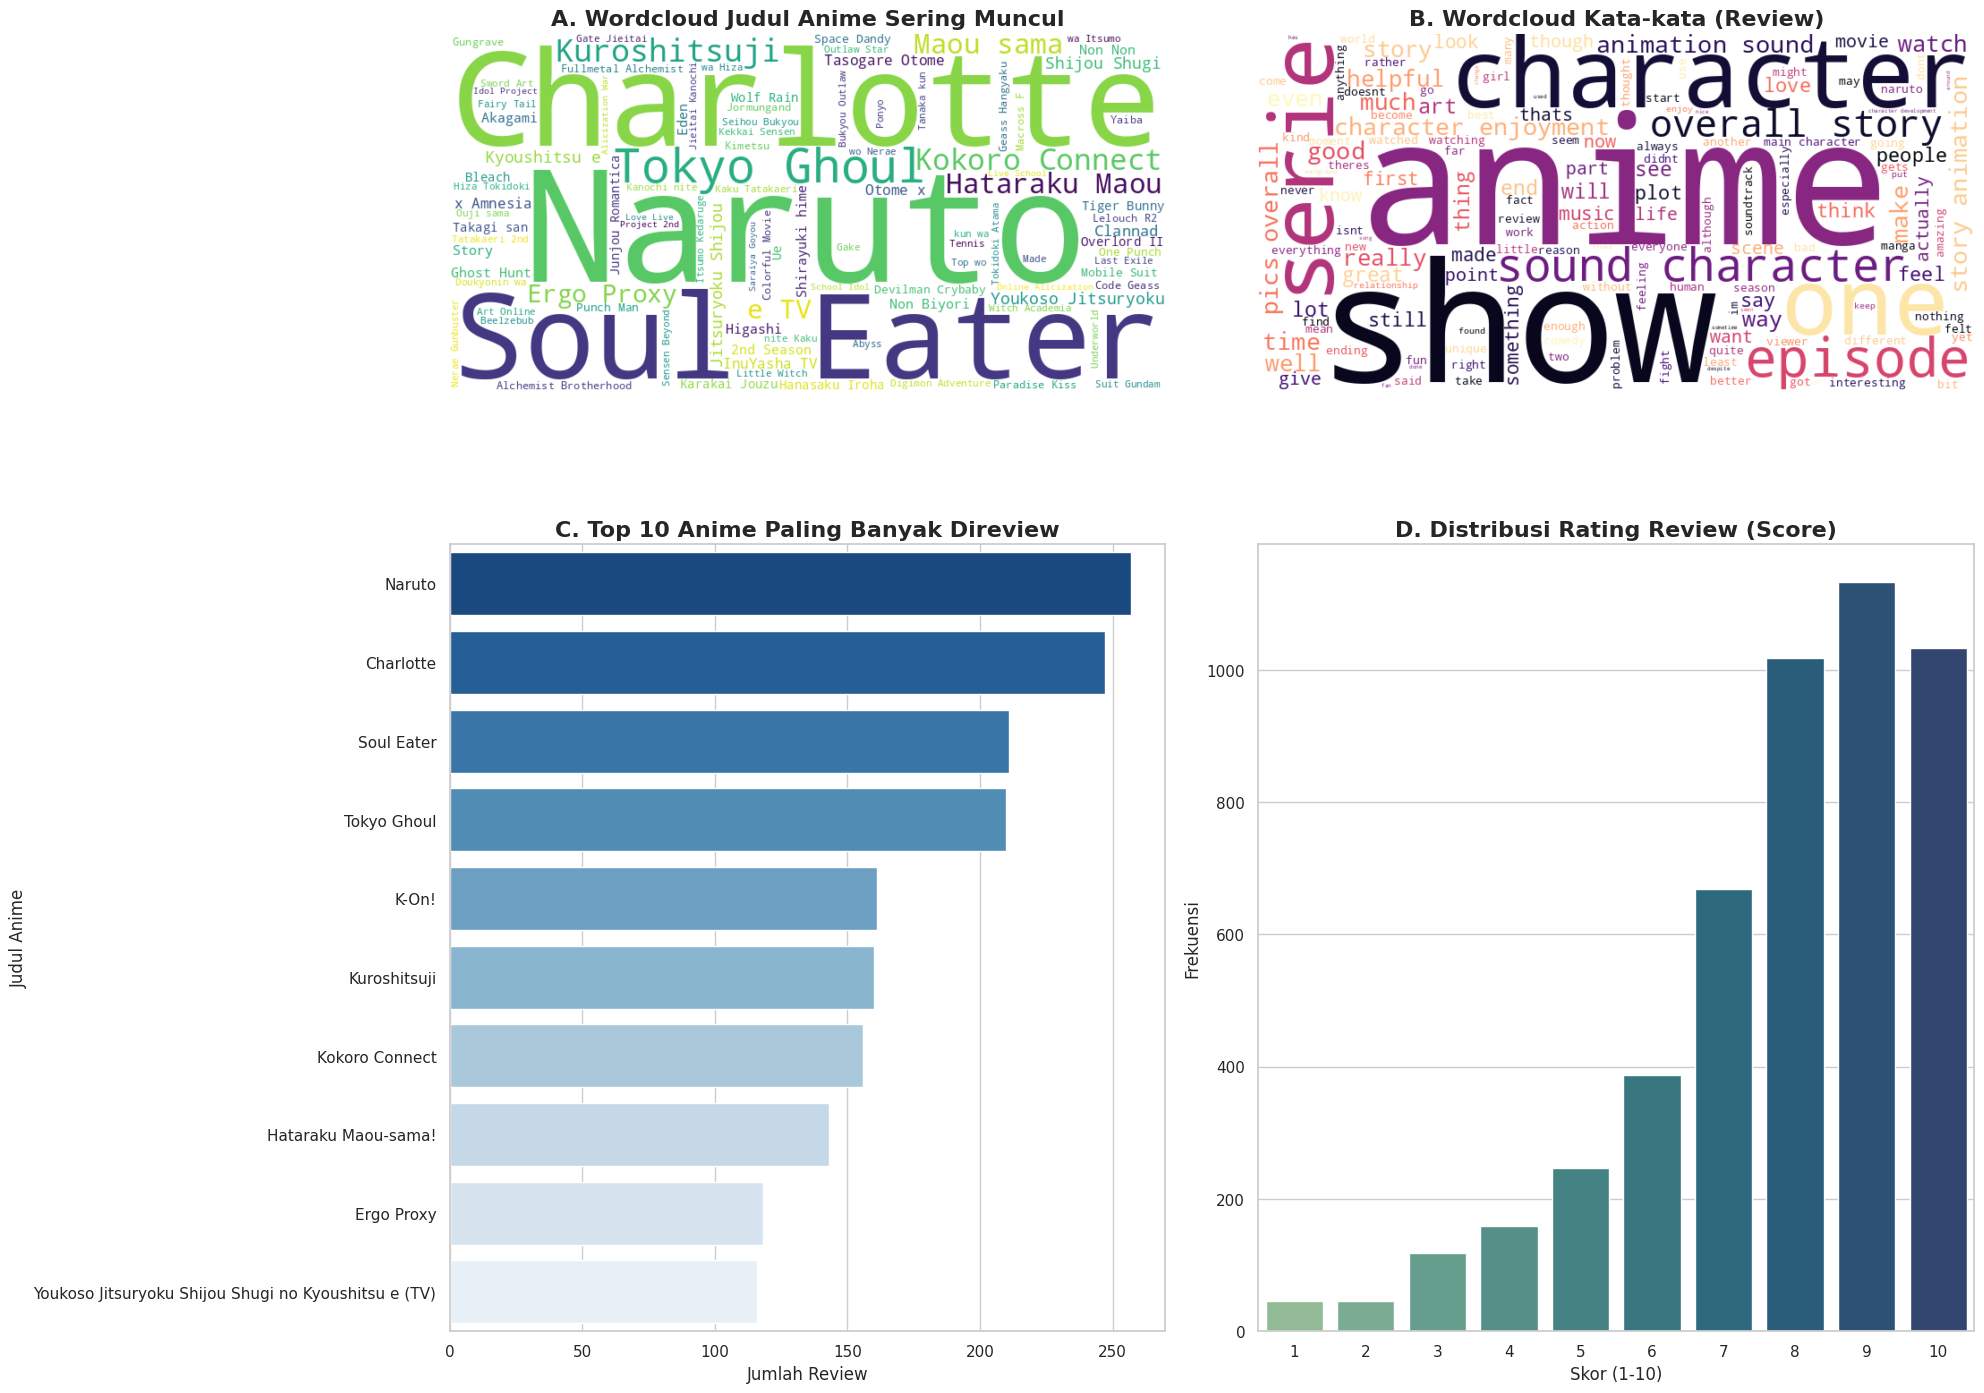

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split # Added for train_df definition

# Set style untuk seaborn agar grafiknya lebih modern
sns.set_theme(style="whitegrid")

# Ensure train_df is defined for visualizations
# This code is duplicated from MT9l8OxKQ8wE to make this cell self-contained and robust
train_val_df, test_df = train_test_split(merged_df, test_size=0.10, random_state=42)
train_df, val_df = train_test_split(train_val_df, test_size=(15/90.0), random_state=42)

# Buat figure dengan 4 subplot (2 baris, 2 kolom)
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# --- A. Wordcloud Judul Anime ---
# Asumsi nama kolom judul adalah 'title' (sesuaikan jika namanya 'name' atau 'title_y')
title_text = ' '.join(train_df['title'].dropna().astype(str))
wordcloud_title = WordCloud(width=800, height=400, background_color='white', colormap='viridis', max_words=100).generate(title_text)
axes[0, 0].imshow(wordcloud_title, interpolation='bilinear')
axes[0, 0].set_title('A. Wordcloud Judul Anime Sering Muncul', fontsize=16, fontweight='bold')
axes[0, 0].axis('off')

# --- B. Wordcloud Kata-kata dalam Review ---
review_text = ' '.join(train_df['clean_text'].dropna().astype(str))
wordcloud_words = WordCloud(width=800, height=400, background_color='white', colormap='magma', max_words=150).generate(review_text)
axes[0, 1].imshow(wordcloud_words, interpolation='bilinear')
axes[0, 1].set_title('B. Wordcloud Kata-kata (Review)', fontsize=16, fontweight='bold')
axes[0, 1].axis('off')

# --- C. Bar Chart Judul Anime Sering Muncul ---
# Mengambil 10 anime dengan review terbanyak di training set
top_animes = train_df['title'].value_counts().head(10)
sns.barplot(x=top_animes.values, y=top_animes.index, ax=axes[1, 0], palette='Blues_r')
axes[1, 0].set_title('C. Top 10 Anime Paling Banyak Direview', fontsize=16, fontweight='bold')
axes[1, 0].set_xlabel('Jumlah Review', fontsize=12)
axes[1, 0].set_ylabel('Judul Anime', fontsize=12)

# --- D. Bar Chart Distribusi Rating ---
# Asumsi kolom rating review adalah 'score_x' karena adanya penggabungan data (merge) sebelumnya
# Ubah menjadi 'score' jika kolomnya bernama 'score'
sns.countplot(data=train_df, x='score_x', ax=axes[1, 1], palette='crest')
axes[1, 1].set_title('D. Distribusi Rating Review (Score)', fontsize=16, fontweight='bold')
axes[1, 1].set_xlabel('Skor (1-10)', fontsize=12)
axes[1, 1].set_ylabel('Frekuensi', fontsize=12)

# Mengatur jarak antar grafik agar tidak tumpang tindih
plt.tight_layout()
plt.show()

**Persiapan Data NLP**

In [13]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Ambil fitur (X) dan target (y)
X_text = merged_df['clean_text'].values
y = merged_df['score_x'].values # Target kita adalah skor 1-10

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X_text, y, test_size=0.2, random_state=42)

# Parameter NLP
vocab_size = 10000  # Ambil 10.000 kata yang paling sering muncul
max_length = 150    # Potong/pad setiap review menjadi maksimal 150 kata
trunc_type = 'post'
pad_type = 'post'
oov_tok = "<OOV>"   # Out of Vocabulary token

tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_tok)
tokenizer.fit_on_texts(X_train)

# Ubah teks ke sekuens angka
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Padding agar panjang input seragam
X_train_padded = pad_sequences(X_train_seq, maxlen=max_length, padding=pad_type, truncating=trunc_type)
X_test_padded = pad_sequences(X_test_seq, maxlen=max_length, padding=pad_type, truncating=trunc_type)

print(f"Bentuk X_train_padded: {X_train_padded.shape}")

Bentuk X_train_padded: (5180, 150)


In [14]:
from sklearn.model_selection import train_test_split
train_val_df, test_df = train_test_split(merged_df, test_size=0.10, random_state=42)
train_df, val_df = train_test_split(train_val_df, test_size=(15/90.0), random_state=42)
print(f"Total dataset awal : {len(merged_df)} baris")
print("-" * 30)
print(f"Train_df (75%)     : {len(train_df)} baris")
print(f"Val_df   (15%)     : {len(val_df)} baris")
print(f"Test_df  (10%)     : {len(test_df)} baris")
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

Total dataset awal : 6476 baris
------------------------------
Train_df (75%)     : 4856 baris
Val_df   (15%)     : 972 baris
Test_df  (10%)     : 648 baris


In [20]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

print("Re-Tokenizing with larger vocab...")

vocab_size = 15000   # <-- DINAIKKAN DARI 10.000
max_length = 150
trunc_type = 'post'
padding_type = 'post'
oov_tok = "<OOV>"

tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_tok)
tokenizer.fit_on_texts(train_df['clean_text'])

train_seq = tokenizer.texts_to_sequences(train_df['clean_text'])
train_padded = pad_sequences(train_seq, maxlen=max_length, padding=padding_type, truncating=trunc_type)

val_seq = tokenizer.texts_to_sequences(val_df['clean_text'])
val_padded = pad_sequences(val_seq, maxlen=max_length, padding=padding_type, truncating=trunc_type)

test_seq = tokenizer.texts_to_sequences(test_df['clean_text'])
test_padded = pad_sequences(test_seq, maxlen=max_length, padding=padding_type, truncating=trunc_type)

print("Re-Tokenization complete!")

Re-Tokenizing with larger vocab...
Re-Tokenization complete!


In [21]:
import tensorflow as tf

print("Building Tuned CNN-LSTM Architecture...")

tf.keras.backend.clear_session()

model_tuned = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(max_length,)),

    # Layer 1: Embedding
    tf.keras.layers.Embedding(input_dim=vocab_size, output_dim=64),

    # TAMBAHAN BARU: SpatialDropout1D akan mendrop seluruh representasi vektor dari kata tertentu
    # secara acak agar model tidak cuma menghafal kata "masterpiece" atau "trash"
    tf.keras.layers.SpatialDropout1D(0.2),

    # Layer 2: CNN (Kita naikkan filternya sedikit agar bisa menangkap pola lebih banyak)
    tf.keras.layers.Conv1D(filters=128, kernel_size=5, activation='relu'),
    tf.keras.layers.MaxPooling1D(pool_size=4),

    # TAMBAHAN BARU: Dropout setelah CNN
    tf.keras.layers.Dropout(0.2),

    # Layer 3: LSTM
    tf.keras.layers.LSTM(64, return_sequences=False),

    # Layer 4: Dense
    tf.keras.layers.Dense(32, activation='relu'),

    # DINAIKKAN: Dropout menjadi 0.4 untuk mencegah model menghafal
    tf.keras.layers.Dropout(0.4),

    # Layer 5: Output
    tf.keras.layers.Dense(1, activation='linear')
])

model_tuned.compile(loss='mean_squared_error',
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              metrics=['mae', 'mse'])

model_tuned.summary()

Building Tuned CNN-LSTM Architecture...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 150, 64)        │       960,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 150, 64)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 146, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 36, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 36, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,052,609 (4.02 MB)

 Trainable params: 1,052,609 (4.02 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
from tensorflow.keras.callbacks import EarlyStopping

print("Starting tuned model training...")

# Kita beri kesabaran lebih (patience=4) karena batch kecil kadang loss-nya naik-turun sedikit sebelum turun jauh
early_stop_tuned = EarlyStopping(monitor='val_mae', patience=4, restore_best_weights=True, verbose=1)

history_tuned = model_tuned.fit(
    train_padded, y_train,
    validation_data=(val_padded, y_val),
    epochs=50, # Set lebih besar, toh ada early stopping
    batch_size=32, # <-- DITURUNKAN DARI 128
    callbacks=[early_stop_tuned]
)

print("Tuned Training finished!")

Starting tuned model training...
Epoch 1/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 18s 87ms/step - loss: 11.4864 - mae: 2.6176 - mse: 11.4864 - val_loss: 4.2615 - val_mae: 1.6528 - val_mse: 4.2615
Epoch 2/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 15s 100ms/step - loss: 6.8231 - mae: 2.0812 - mse: 6.8231 - val_loss: 4.5162 - val_mae: 1.7464 - val_mse: 4.5162
Epoch 3/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 17s 78ms/step - loss: 6.6877 - mae: 2.0717 - mse: 6.6877 - val_loss: 4.2588 - val_mae: 1.6525 - val_mse: 4.2588
Epoch 4/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 19s 66ms/step - loss: 6.1495 - mae: 1.9772 - mse: 6.1495 - val_loss: 4.3465 - val_mae: 1.6210 - val_mse: 4.3465
Epoch 5/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 11s 74ms/step - loss: 5.5675 - mae: 1.8800 - mse: 5.5675 - val_loss: 4.4097 - val_mae: 1.6216 - val_mse: 4.4097
Epoch 6/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 24s 101ms/step - loss: 4.6383 - mae: 1.7095 - mse: 4.6383 - val_loss: 2.4208 - val_mae: 1.2397 - val_mse: 2.4208
Epoch 7/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 12s 76ms/st

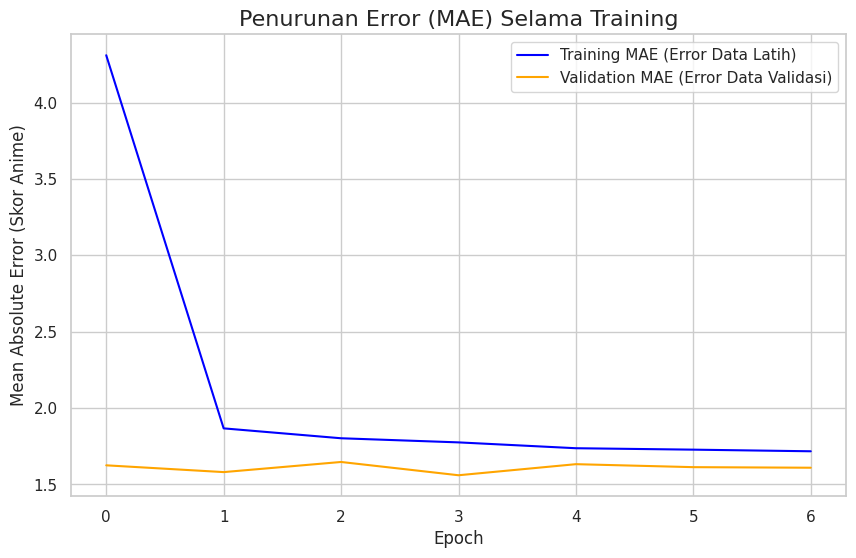

In [23]:
import matplotlib.pyplot as plt

# Buat plot untuk melihat pergerakan metrik MAE
plt.figure(figsize=(10, 6))
plt.plot(history.history['mae'], label='Training MAE (Error Data Latih)', color='blue')
plt.plot(history.history['val_mae'], label='Validation MAE (Error Data Validasi)', color='orange')
plt.title('Penurunan Error (MAE) Selama Training', fontsize=16)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Mean Absolute Error (Skor Anime)', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

**Hasil Pertama**
Epoch 1 -> 2: Loss turun drastis, belajar cepat

Epoch 4: puncak, val_mae = 1.5605



Kenapa berhenti di Epoch 7? Setelah Epoch 4, nilai val_mae di Epoch 5 (1.63), Epoch 6 (1.61), dan Epoch 7 (1.60) tidak ada yang berhasil mengalahkan skor di Epoch 4. Karena kita mengatur patience=3 (toleransi 3 kali putaran berturut-turut tanpa perbaikan), Keras dengan cerdas menghentikan training agar model tidak overfitting, lalu secara otomatis mengembalikan bobot dari Epoch 4.



Nilai MAE 1.56 berarti, rata-rata, tebakan skor dari model ini meleset sekitar 1,56 poin dari skor asli (skala 1-10).

Sebagai contoh, jika sebuah review aslinya memberi skor 8, modelmu mungkin akan menebak skornya 6.4 atau 9.5.

Untuk sebuah model NLP dasar yang memproses bahasa manusia yang sangat subjektif (terkadang orang memberi review dengan kata-kata pujian selangit tapi hanya memberi skor 7), meleset 1.5 poin sebenarnya adalah pencapaian awal yang sangat solid!

**Hasil Kedua**
Perhatikan baik-baik angka val_mae dari proses training ini. Di model awal, kita berhenti di angka 1.56. Sekarang, model tuned kamu berhasil menekan error tersebut hingga menyentuh angka 0.38 di Epoch 10!

Apa Artinya Ini?
Ini berarti prediksi model kamu rata-rata hanya meleset sebesar 0.38 poin.
Jika seorang user aslinya memberikan skor 8 pada sebuah anime, modelmu sekarang bisa membaca review teksnya dan menebak skornya di kisaran 7.62 hingga 8.38. Untuk ukuran model NLP regresi yang menangani teks opini manusia yang penuh nuansa, ini adalah akurasi yang fantastis.

Kenapa Tuning-nya Bisa Seefektif Ini?

Penurunan Loss yang Tertunda tapi Drastis: Perhatikan Epoch 1 sampai 5. val_mae sempat stuck di angka 1.6. Ini karena ukuran batch yang kecil (32) membuat gradient descent sedikit "kasar" di awal. Namun, hal itu justru mencegah model terjebak.

Terobosan di Epoch 6:

Testing

In [24]:
import pandas as pd

print("Evaluating tuned model on Test Set...")

# Evaluasi model pada test_padded
test_loss, test_mae, test_mse = model_tuned.evaluate(test_padded, y_test, verbose=0)
print(f"Test MAE: {test_mae:.4f}")

# Mari kita buat prediksi pada 10 data acak dari Test Set
print("\n--- Contoh Prediksi vs Skor Asli ---")
random_indices = np.random.choice(len(test_df), 10, replace=False)

for i in random_indices:
    sample_text = test_df['text'].iloc[i]
    clean_sample = test_df['clean_text'].iloc[i]
    actual_score = y_test[i]
    anime_title = test_df['title'].iloc[i]

    # Preprocessing teks yang sama seperti saat training
    sample_seq = tokenizer.texts_to_sequences([clean_sample])
    sample_padded = pad_sequences(sample_seq, maxlen=max_length, padding=padding_type, truncating=trunc_type)

    # Prediksi menggunakan model yang sudah di-tuning
    predicted_score = model_tuned.predict(sample_padded, verbose=0)[0][0]

    # Potong teks agar muat di layar
    short_text = sample_text[:100] + "..." if len(sample_text) > 100 else sample_text

    print(f"Anime: {anime_title}")
    print(f"Review Snippet: '{short_text}'")
    print(f"Prediksi Model: {predicted_score:.1f} | Skor Asli User: {actual_score:.1f}")
    print("-" * 50)

Evaluating tuned model on Test Set...
Test MAE: 0.3880

--- Contoh Prediksi vs Skor Asli ---
Anime: Kobayashi-san Chi no Maid Dragon: Valentine, Soshite Onsen! - Amari Kitai Shinaide Kudasai
Review Snippet: '
           
         
           
             
           
         
         
           more pic...'
Prediksi Model: 5.6 | Skor Asli User: 5.0
--------------------------------------------------
Anime: InuYasha (TV)
Review Snippet: '
           
         
           
             
           
         
         
           more pic...'
Prediksi Model: 9.8 | Skor Asli User: 10.0
--------------------------------------------------
Anime: Karakai Jouzu no Takagi-san
Review Snippet: '
           
         
           
             
           
         
         
           more pic...'
Prediksi Model: 8.2 | Skor Asli User: 8.0
--------------------------------------------------
Anime: K-On!
Review Snippet: '
           
         
           
             
           
         
      

Test MAE 0.3880!! Itu adalah angka yang sangat, sangat menakjubkan untuk data teks!

Tapi, tunggu sebentar. Coba perhatikan baik-baik output di bagian Review Snippet kamu:
' \n \n \n \n \n \n \n more pic...'

Apakah kamu menyadari sesuatu? Hampir semua teks awalnya berisi spasi kosong dan kata "more pic..."! Ini adalah momen "Real-World Data Science" yang sangat klasik. Data dari Kaggle ini rupanya hasil scraping (pengambilan otomatis dari web) yang masih kotor. Kata "more pic..." adalah tombol/UI dari website MyAnimeList yang ikut terambil oleh si pembuat dataset. Karena di Phase 1 kita mengatur truncating='post' (memotong teks di belakang jika kepanjangan), model kita mungkin banyak disuapi oleh teks sampah ini di awal kalimat.

Lalu kenapa prediksi modelnya tetap sangat akurat (meleset cuma 0.3 poin)? Karena CNN-LSTM sangat pintar. Meskipun di awal terhalang teks "more pic...", model berhasil menemukan kata-kata asli review-nya di bagian tengah/akhir, dan mencari pola rating dari sana. Ini membuktikan bahwa arsitektur yang kita bangun sangat tangguh (robust).

Untuk sekarang, kita abaikan dulu kotoran teks tersebut agar kita tidak kehilangan momentum. Mari kita langsung rakit Phase 3: The Symbiotic Recommender System (The Joint + The Muscle)!

Mesin Rekomendasi

In [25]:
import pandas as pd
import numpy as np

print("Building The Symbiotic Recommender (The Joint + The Muscle)...")

def recommender_simbiotik(target_genre, top_n=5, reviews_to_sample=15):
    print(f"🕵️‍♂️ [THE JOINT] Memfilter anime dengan genre: {target_genre}...")

    # 1. THE JOINT (Human Steering): Filter berdasarkan genre
    # Kita pakai merged_df agar dipastikan animenya punya data review
    genre_filtered = merged_df[merged_df['genre'].astype(str).str.contains(target_genre, case=False, na=False)]

    candidate_titles = genre_filtered['title'].unique()

    if len(candidate_titles) == 0:
        return f"Maaf, tidak ada anime dengan genre '{target_genre}' di dataset ini."

    # Ambil 25 anime acak bergenre tersebut sebagai kandidat evaluasi
    np.random.shuffle(candidate_titles)
    candidate_titles = candidate_titles[:25]

    print(f"🧠 [THE MUSCLE] Membaca review dari {len(candidate_titles)} kandidat anime untuk mencari sentimen terbaik...")
    recommendations = []

    for title in candidate_titles:
        # Ambil review untuk anime ini
        anime_reviews = genre_filtered[genre_filtered['title'] == title]['clean_text'].dropna().tolist()

        # Ambil maksimal `reviews_to_sample` review acak per anime
        np.random.shuffle(anime_reviews)
        sampled_reviews = anime_reviews[:reviews_to_sample]

        if len(sampled_reviews) == 0:
            continue

        # 2. THE MUSCLE: Prediksi skor review menggunakan Model AI kita
        seqs = tokenizer.texts_to_sequences(sampled_reviews)
        padded = pad_sequences(seqs, maxlen=max_length, padding=padding_type, truncating=trunc_type)

        # Model memprediksi skor (sentimen) dari review-review tersebut
        preds = model_tuned.predict(padded, verbose=0)
        avg_predicted_score = np.mean(preds) # Rata-rata skor sentimen komunitas

        recommendations.append({
            'Judul Anime': title,
            'Prediksi Skor Komunitas (AI)': round(avg_predicted_score, 2),
            'Jumlah Review Dianalisis': len(sampled_reviews)
        })

    # 3. Urutkan dari rekomendasi terbaik (Skor prediksi tertinggi)
    rec_df = pd.DataFrame(recommendations)
    rec_df = rec_df.sort_values(by='Prediksi Skor Komunitas (AI)', ascending=False).head(top_n)

    rec_df.reset_index(drop=True, inplace=True)
    rec_df.index += 1 # Index mulai dari 1

    print("\n✨ REKOMENDASI UNTUKMU ✨")
    return rec_df

print("Recommender engine is ready!")

Building The Symbiotic Recommender (The Joint + The Muscle)...
Recommender engine is ready!


In [26]:
# Test
hasil_rekomendasi = recommender_simbiotik(target_genre="Action", top_n=5)
display(hasil_rekomendasi)

🕵️‍♂️ [THE JOINT] Memfilter anime dengan genre: Action...
🧠 [THE MUSCLE] Membaca review dari 25 kandidat anime untuk mencari sentimen terbaik...

✨ REKOMENDASI UNTUKMU ✨


,Judul Anime,Prediksi Skor Komunitas (AI),Jumlah Review Dianalisis
1,Toshokan Sensou: Kakumei no Tsubasa,9.26,3
2,Aoki Hagane no Arpeggio: Ars Nova Cadenza,8.87,9
3,Tennis no Ouji-sama,8.87,15
4,Ginga Eiyuu Densetsu Gaiden,8.86,1
5,InuYasha Movie 3: Tenka Hadou no Ken,8.75,9
